In [1]:
import numpy as np
import matplotlib.pyplot as plt
from model import Kernel
from model import utils as mutils
import importlib
import torch


In [2]:
configs=importlib.import_module('configs.Unet.unet_ds')
config=configs.get_config()

In [3]:
model=mutils.create_model(config)

In [6]:
ckt=torch.load('/home/cidar/Desktop/MRI_superres_registration/Kernel_Learning/workdir/checkpoints-meta/checkpoint.pth')
model.load_state_dict(ckt['model'])

<All keys matched successfully>

In [12]:
hr_image=np.load('/home/cidar/Desktop/MRI_superres_registration/test/HR/AD_F11_90_AD_F11_90_slice_40.npy').astype(np.float32)
lr_image=np.load('/home/cidar/Desktop/MRI_superres_registration/test/LR/AD_F11_90_AD_F11_90_slice_40.npy').astype(np.float32)

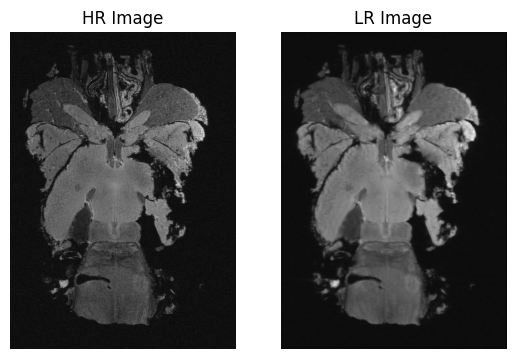

In [13]:
plt.subplot(1,2,1)
plt.imshow(hr_image,cmap='gray')
plt.title('HR Image')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(lr_image,cmap='gray')
plt.title('LR Image')
plt.axis('off')
plt.show()

In [14]:
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

In [15]:
psnr=peak_signal_noise_ratio(hr_image,lr_image,data_range=1.0)
ssim=structural_similarity(hr_image,lr_image,data_range=1.0)
print('PSNR:',psnr)
print('SSIM:',ssim)

PSNR: 33.93003461383038
SSIM: 0.8375160864198309


In [16]:
hr_tensor=torch.from_numpy(hr_image).unsqueeze(0).unsqueeze(0).to(torch.device('cuda'))
lr_pred=model(hr_tensor)

In [17]:
lr_pred=lr_pred.squeeze(0).squeeze(0).detach().cpu().numpy()

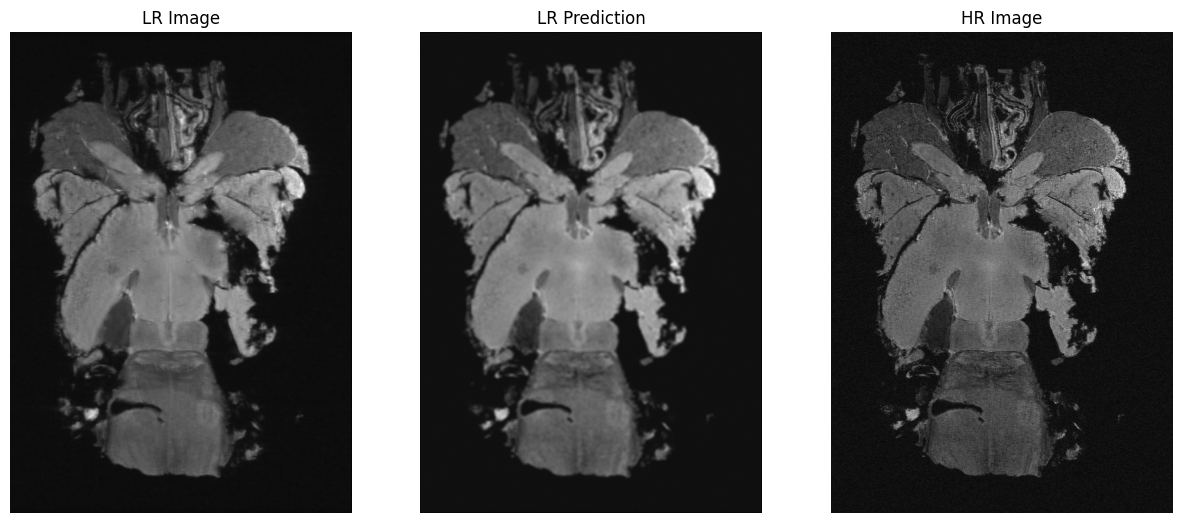

In [18]:
plt.figure(figsize=(15,15))
plt.subplot(1,3,1)
plt.imshow(lr_image,cmap='gray')
plt.title('LR Image')
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(lr_pred,cmap='gray')
plt.title('LR Prediction')
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(hr_image,cmap='gray')
plt.title('HR Image')
plt.axis('off')
plt.show()

In [21]:
psnr=peak_signal_noise_ratio(lr_pred,hr_image,data_range=1.0)
ssim=structural_similarity(lr_pred,hr_image,data_range=1.0)
print('PSNR:',psnr)
print('SSIM:',ssim)

PSNR: 34.75048584678454
SSIM: 0.8828825430602207


In [22]:
lr_pred

array([[0.0041028 , 0.01203933, 0.01060761, ..., 0.01053066, 0.00928421,
        0.0132749 ],
       [0.01773417, 0.0189562 , 0.02058063, ..., 0.02126843, 0.01906563,
        0.00829019],
       [0.01933531, 0.022828  , 0.02491616, ..., 0.02562682, 0.02118547,
        0.01152295],
       ...,
       [0.01933216, 0.02176087, 0.02516847, ..., 0.02396509, 0.02196737,
        0.01105062],
       [0.01772158, 0.01862394, 0.02090728, ..., 0.02158887, 0.01928305,
        0.01098306],
       [0.01543656, 0.01188482, 0.01520794, ..., 0.01453471, 0.01348198,
        0.00963497]], dtype=float32)